In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')
sys.path.insert(1, r'C:\Users\tomaz.bregar\Desktop\git_projects\pyEMA')

In [2]:
import pyFBS
from pyEMA import pyEMA
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
from time import time,sleep
from pyFBS.utility import *

In [3]:
from scipy.spatial.transform import Rotation as R
import numpy as np

## Example of modal analysis on a simple beam

#### 3D View
Open 3Dviewer in the background, with CSYS in origin

In [4]:
view3D = pyFBS.view3D()

Add a structure from .stl file to the 3D 

In [5]:
stl = pyFBS.example_auto_testbench["STL"]
stl

{'ts': '..\\data\\automotive_testbench\\STL\\ts.stl',
 'transmission_mount': '..\\data\\automotive_testbench\\STL\\transmission_mount.stl',
 'shaker_only': '..\\data\\automotive_testbench\\STL\\shaker_only.stl',
 'roll_mount': '..\\data\\automotive_testbench\\STL\\roll_mount.stl',
 'receiver': '..\\data\\automotive_testbench\\STL\\receiver.stl',
 'engine_mount': '..\\data\\automotive_testbench\\STL\\engine_mount.stl'}

In [6]:
stl = pyFBS.example_auto_testbench["STL"]["receiver"]
mesh, _ = view3D.add_stl(stl,name = "receiver",color = "#D3D3D3",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["transmission_mount"]
_, _ = view3D.add_stl(stl,name = "transmission_mount",color = "#D3D3D3",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["roll_mount"]
_, _ = view3D.add_stl(stl,name = "roll_mount",color = "#D3D3D3",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["engine_mount"]
_, _ = view3D.add_stl(stl,name = "engine_mount",color = "#D3D3D3",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["ts"]
_, _ = view3D.add_stl(stl,name = "ts",color = "#D3D3D3",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["shaker_only"]
_, _ = view3D.add_stl(stl,name = "shaker_only",color = "#D3D3D3",opacity = .1)

In [7]:
AB = r"C:\Users\tomaz.bregar\Desktop\AutomotiveTPATeststructure_modalanalysis\geometry_pyFBS.xlsx"

In [8]:
AB = "./modal_analysis.xlsx"
df_acc = pd.read_excel(AB, sheet_name='Sensors')

view3D.show_acc(df_acc)
view3D.label_acc(df_acc)

#### Channels
Add corresponding channels from .xlsx file together with appropriate labels

In [9]:
df_chn = pd.read_excel(AB, sheet_name='Channels')
#view3D.show_chn(df_chn)

#### Impacts
Add impacts from .xlsx with appropriate labels

In [69]:
df_imp = pd.read_excel(AB, sheet_name='Impacts')

view3D.show_imp(df_imp)
view3D.label_imp(df_imp)

In [60]:
import pyuff
from pyFBS.io import * 

In [61]:
file_input = r"C:\Users\tomaz.bregar\Desktop\AutomotiveTestbenchModalanalysisAssembly\190712_Hyundai_Modalanalysis_Modalanalyse.analysis_1_1_H.uf"
file_output = r"C:\Users\tomaz.bregar\Desktop\AutomotiveTestbenchModalanalysisAssembly\190712_Hyundai_Modalanalysis_Modalanalyse.analysis_1_1_S.uf"
file_data = r"C:\Users\tomaz.bregar\Desktop\AutomotiveTestbenchModalanalysisAssembly\190712_Hyundai_Modalanalysis_Modalanalyse.analysis_1_1.uf"


freq,FRF,_,_,_,_ = load_uff_file_PAK(file_data,file_output,file_input)


Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.


,Name,Description,Type,DirectionLabel,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
50,S17z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.39,0.0,0.26,-1.224647e-16,-1.0,1.874700e-33


,Name,Description,Type,DirectionLabel,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
10,H11,NaN,NaN,-Z,NaN,NaN,NaN,NaN,NaN,0.29,0.46,0.292,0,0,-1


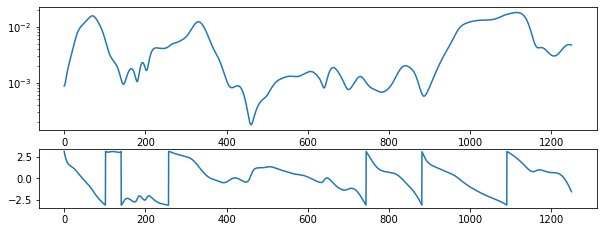

In [62]:
_out = 50
_in = 10



plt.figure(figsize = (10,5))
plt.subplot(211)
plt.semilogy(freq,np.abs(FRF[:,_out,_in]))

plt.subplot(413)
plt.plot(freq,np.angle(FRF[:,_out,_in]))


display(df_chn.iloc[[_out]])
display(df_imp.iloc[[_in]])


### Modal analysis
First load the data

In [140]:
Y =  FRF[:,:,0] #np.load("../data/LADISK_beam/Measurements/modal.npy",allow_pickle = True)

Y = Y.T
Y.shape

(135, 3201)

Modeshape identification using pyEMA (LSCF/LSFD)

In [141]:
a = pyEMA.Model(
    Y,
    freq,
    pol_order_high=60,
    lower = 0,
    upper = 1000
    )

a.get_poles()

fn_temp, xi_temp, test_fn, test_xi = pyEMA.stabilisation(a.all_poles, a.pol_order_high, err_fn=1, err_xi=0.5)

#approx_nat_freq = [64,97,109,136,163,212]
#a.select_closest_poles(approx_nat_freq)
a.stab_chart()

H_acc, A_acc = a.get_constants(whose_poles=a,least_squares_type="old")
_modes_acc = modeshape_scaling_DP(A_acc,0)

#new_mode = unflattenFRFs(_modes_acc,Y)

100%|██████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 138.04it/s]


SHIFT + LEFT mouse button to pick a pole.
RIGHT mouse button to erase the last pick.
1. Frequency: ~262 -->	260.13459235963455 Hz	(xi = 0.0629)
2. Frequency: ~86 -->	86.29246508197204 Hz	(xi = 0.2123)
Deleting the last pick...
2. Frequency: ~182 -->	182.3011574641722 Hz	(xi = 0.1040)
3. Frequency: ~214 -->	212.45255571471318 Hz	(xi = 0.0733)
Deleting the last pick...
Deleting the last pick...
2. Frequency: ~377 -->	379.09187038648423 Hz	(xi = 0.0493)
3. Frequency: ~832 -->	832.5596743679307 Hz	(xi = 0.0216)
4. Frequency: ~822 -->	818.5166304693865 Hz	(xi = 0.0208)
5. Frequency: ~576 -->	571.8493336585072 Hz	(xi = 0.0402)
Deleting the last pick...
5. Frequency: ~665 -->	660.3618029512537 Hz	(xi = 0.0292)
6. Frequency: ~687 -->	689.9215202988996 Hz	(xi = 0.0279)
Deleting the last pick...
Deleting the last pick...
5. Frequency: ~953 -->	952.7980412929768 Hz	(xi = 0.0184)
Deleting the last pick...


<Figure size 432x288 with 0 Axes>

In [160]:
df = pd.read_excel(AB, sheet_name='Sensors')
pos_array = df[["Position_1","Position_2","Position_3"]].to_numpy()*1000

faces = np.hstack([[2,7,22],[2,22,11],[2,11,24],[2,24,9],[2,27,9],[2,27,0],[2,0,12],[2,27,12],[2,0,15],[2,19,15],[2,19,12],[2,0,19],[2,4,15],[2,4,19],[2,4,20],[2,20,5],[2,7,5],[2,18,3],[2,3,34],[2,34,43],[2,34,33],[2,43,33],[2,33,13]
                  ,[2,13,21],[2,21,6],[2,8,6],[2,8,23],[2,23,25],[2,10,25],[2,10,29],[2,2,29],[2,2,14],[2,18,14],[2,1,18],[2,14,16],[2,4,16],[2,7,28],[2,28,21],[2,8,26],[2,26,11],[2,8,38],[2,39,38],[2,39,40],[2,25,40],[2,23,40],[2,38,23]
                  ,[2,36,37],[2,36,41],[2,41,42],[2,42,31],[2,31,35],[2,35,37],[2,32,44],[2,30,44],[2,17,44],[2,17,30],[2,30,2],[2,17,14]]).astype(np.int8)

#point_cloud = pv.PolyData(pos_array)

point_cloud1 = pv.PolyData(pos_array,faces)
pts = point_cloud1.points.copy()



#actor_points = view3D.plot.add_mesh(point_cloud1,name = "mesh",render_points_as_spheres = True,render_lines_as_tubes = True, color = "k",point_size = 10,clim = [-1,1], cmap="viridis",scalars = np.zeros(pts.shape[0]),style = "points",show_edges = True)
actor_points = view3D.plot.add_mesh(point_cloud1,name = "meshP",render_lines_as_tubes = True, line_width=3, color = "k",point_size = 10,clim = [-1,1], cmap="viridis",scalars = np.zeros(pts.shape[0]),style = "wireframe")

In [161]:

n_sen = pts.shape[0]
n_ax = pts.shape[1]

empty = np.zeros_like(pts,dtype = complex)

# channel data for animation!
_dir = df_chn[["Direction_1","Direction_2","Direction_3"]].to_numpy()
for i in range(n_sen):
    for j in range(n_ax):
        sel = (i)*3+j
        empty[i,:] += _dir[sel:sel+1,:].T@np.asarray([_modes_acc[sel,1]])
        

In [162]:
scale = 50

mode_dict = dict()


mode_dict["animation_pts"] = mode_animation(empty,scale,no_points = 60)
mode_dict["mesh"] = point_cloud1
mode_dict["or_pts"] = pts

mode_dict["scalars"] = True
mode_dict["fps"] = 30

view3D.add_modeshape(mode_dict,run_animation = True)

In [ ]:
mode_dict = dict_animation(empty,"object",object_list = view3D.global_acc,r_scale = 50)

view3D.add_objects_animation(mode_dict,run_animation = True,add_note= False)